In [26]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import math

In [31]:
script = pd.read_csv('red_clump_analysis_script_2.csv')

slopes = script['slope_1']
d_slopes = script['d_slope_1']

NRCB1_slopes    = np.array(slopes[0:10])
NRCB1_d_slopes  = np.array(d_slopes[0:10])
NRCB2_slopes    = np.array(slopes[10:20])
NRCB2_d_slopes  = np.array(d_slopes[10:20])
NRCB3_slopes    = np.array(slopes[20:30])
NRCB3_d_slopes  = np.array(d_slopes[20:30])
NRCB4_slopes    = np.array(slopes[30:40])
NRCB4_d_slopes  = np.array(d_slopes[30:40])
NRCB5_slopes    = np.array(slopes[40:])
NRCB5_d_slopes  = np.array(d_slopes[40:])

A_115_212, Ae_115_212 = [], []
A_323_212, Ae_323_212 = [], []
A_405_212, Ae_405_212 = [], []

for i in [NRCB1_slopes, NRCB2_slopes, NRCB3_slopes, NRCB4_slopes]: 
    A_115_212.append(i[0] / i[1])
    A_323_212.append(i[7] / i[6])
    A_405_212.append(i[9] / i[8])

Ae_115_212.append(A_115_212[0] * math.sqrt( (NRCB1_d_slopes[0] / NRCB1_slopes[0])**2 + (NRCB1_d_slopes[1] / NRCB1_slopes[1])**2 ))
Ae_115_212.append(A_115_212[1] * math.sqrt( (NRCB2_d_slopes[0] / NRCB2_slopes[0])**2 + (NRCB2_d_slopes[1] / NRCB2_slopes[1])**2 ))
Ae_115_212.append(A_115_212[2] * math.sqrt( (NRCB3_d_slopes[0] / NRCB3_slopes[0])**2 + (NRCB3_d_slopes[1] / NRCB3_slopes[1])**2 ))
Ae_115_212.append(A_115_212[3] * math.sqrt( (NRCB4_d_slopes[0] / NRCB4_slopes[0])**2 + (NRCB4_d_slopes[1] / NRCB4_slopes[1])**2 ))

Ae_323_212.append(A_323_212[0] * math.sqrt( (NRCB1_d_slopes[7] / NRCB1_slopes[7])**2 + (NRCB1_d_slopes[6] / NRCB1_slopes[6])**2 ))
Ae_323_212.append(A_323_212[1] * math.sqrt( (NRCB2_d_slopes[7] / NRCB2_slopes[7])**2 + (NRCB2_d_slopes[6] / NRCB2_slopes[6])**2 ))
Ae_323_212.append(A_323_212[2] * math.sqrt( (NRCB3_d_slopes[7] / NRCB3_slopes[7])**2 + (NRCB3_d_slopes[6] / NRCB3_slopes[6])**2 ))
Ae_323_212.append(A_323_212[3] * math.sqrt( (NRCB4_d_slopes[7] / NRCB4_slopes[7])**2 + (NRCB4_d_slopes[6] / NRCB4_slopes[6])**2 ))

Ae_405_212.append(A_405_212[0] * math.sqrt( (NRCB1_d_slopes[9] / NRCB1_slopes[9])**2 + (NRCB1_d_slopes[8] / NRCB1_slopes[8])**2 ))
Ae_405_212.append(A_405_212[1] * math.sqrt( (NRCB2_d_slopes[9] / NRCB2_slopes[9])**2 + (NRCB2_d_slopes[8] / NRCB2_slopes[8])**2 ))
Ae_405_212.append(A_405_212[2] * math.sqrt( (NRCB3_d_slopes[9] / NRCB3_slopes[9])**2 + (NRCB3_d_slopes[8] / NRCB3_slopes[8])**2 ))
Ae_405_212.append(A_405_212[3] * math.sqrt( (NRCB4_d_slopes[9] / NRCB4_slopes[9])**2 + (NRCB4_d_slopes[8] / NRCB4_slopes[8])**2 ))

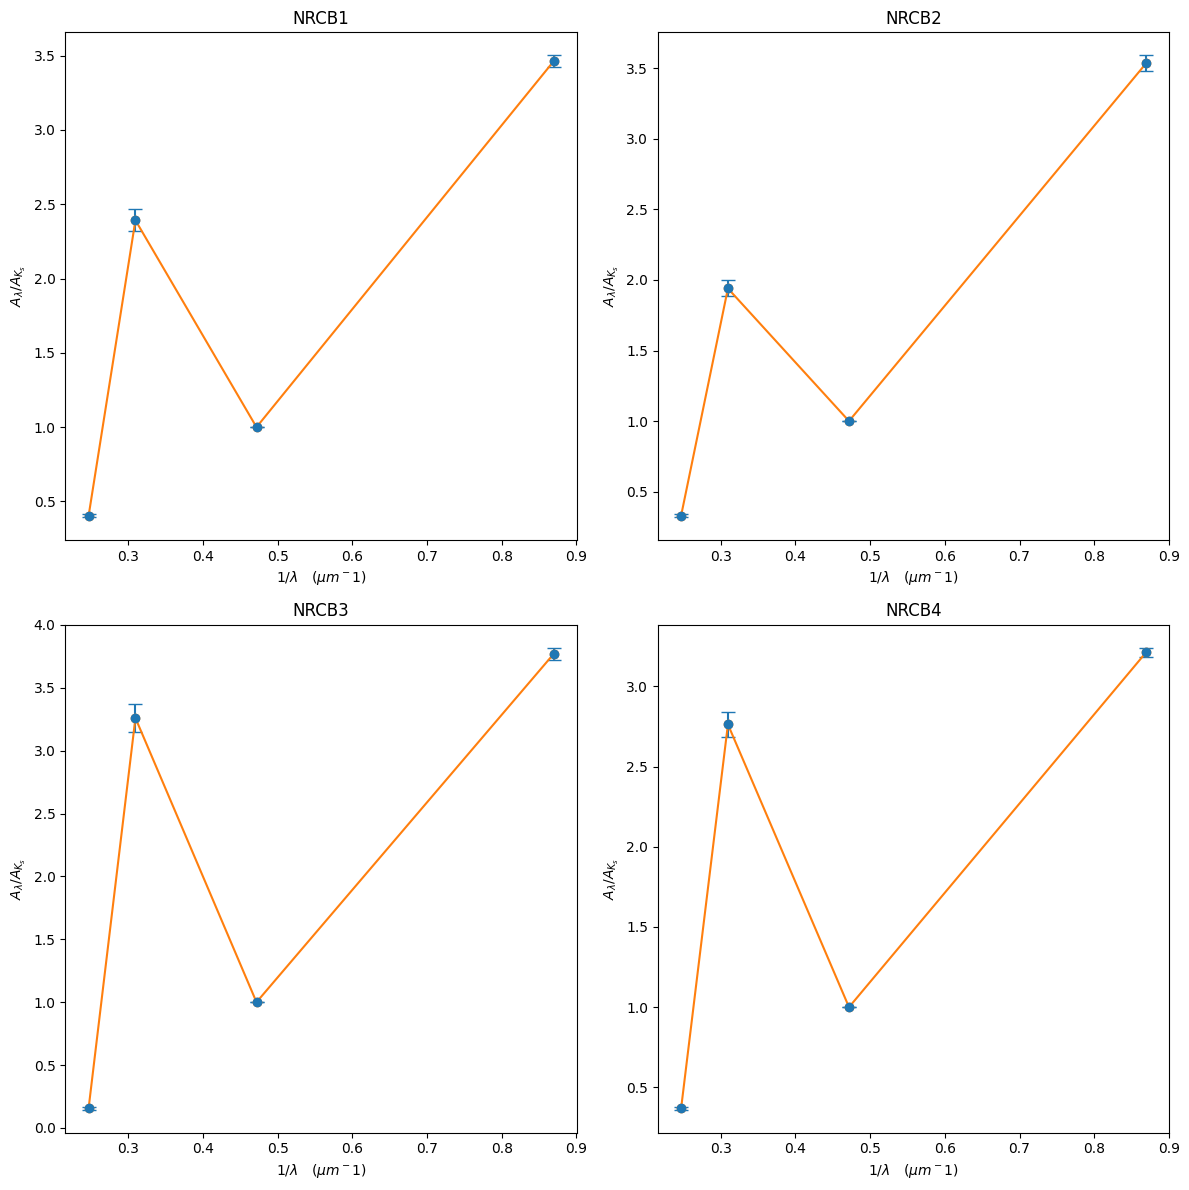

In [72]:
fig, axis = plt.subplots(2, 2, figsize = (12, 12))

x_values = [1/1.15, 1/2.12, 1/3.23, 1/4.05]

for i in range(2):
    for j in range(2):
        axis[i, j].set_xlabel(r'$1 / \lambda \quad (\mu m^-1)$')
        axis[i, j].set_ylabel(r"$A_{\lambda} / A_{K_s}$")

titles = ['NRCB1', 'NRCB2', 'NRCB3', 'NRCB4']
for idx, ax in enumerate(axis.flatten()):
    ax.set_title(titles[idx])
    
    y_values = [A_115_212[idx], 1, A_323_212[idx], A_405_212[idx]]
    y_errors = [Ae_115_212[idx], 0, Ae_323_212[idx], Ae_405_212[idx]]
    
    ax.errorbar(x_values, y_values, yerr=y_errors, fmt='o', capsize=5)
    
    ax.plot(x_values, y_values, linestyle='-', marker='o')

plt.tight_layout()
plt.show()

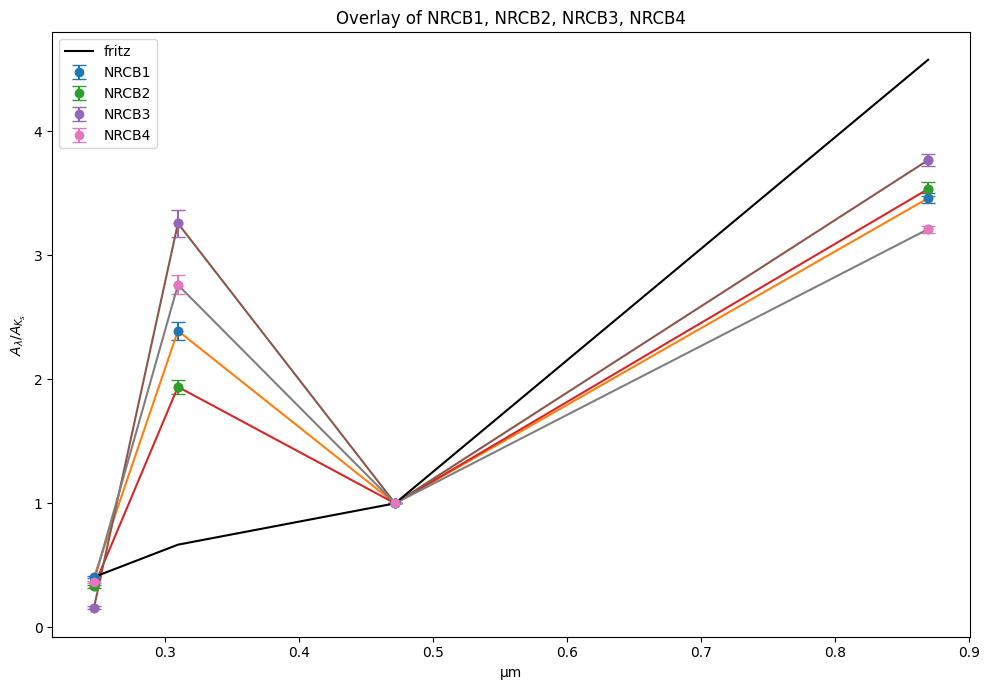

In [78]:
fig, ax = plt.subplots(figsize=(10, 7))

for idx, title in enumerate(titles):
    # Collect y-values and errors for the current dataset
    y_values = [A_115_212[idx], 1, A_323_212[idx], A_405_212[idx]]
    y_errors = [Ae_115_212[idx], 0, Ae_323_212[idx], Ae_405_212[idx]]
    
    ax.errorbar(x_values, y_values, yerr=y_errors, fmt='o', capsize=5, label=title)
    
    ax.plot(x_values, y_values, linestyle='-', marker='o')

plt.plot(x_values, y_orig, c = 'k', label = 'fritz')

ax.set_xlabel('µm')
ax.set_ylabel(r"$A_{\lambda} / A_{K_s}$")
ax.set_title('Overlay of NRCB1, NRCB2, NRCB3, NRCB4')

ax.legend()

plt.tight_layout()
plt.show()

In [76]:
A_212 = 2.49
A_115 = 11.4
A_323 = 1.66
A_405 = 1.01

A_115_212_orig = 11.4 / 2.49
A_323_212_orig = 1.66 / 2.49
A_405_212_orig = 1.01 / 2.49

y_orig = [A_115_212_orig, 1, A_323_212_orig, A_405_212_orig]
y_orig

[4.578313253012048, 1, 0.6666666666666666, 0.40562248995983935]

In [79]:
1/2.12

0.4716981132075471